# Quick Start

This notebook follows the same two YAML files as the documentation. Starting from an empty `data/` directory, PyHermes downloads and caches a compact Quijote halo catalogue, projects it into a reusable `SFCField`, measures an isotropic 2PCF, reloads the saved result, and plots it.

The first run downloads about 9 MB. Later runs reuse `./data/quijote_halos_8000_snap004.npz`.


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt

from pyhermes.base.sfc_projection import SFCProjection
from pyhermes.io import Corr2PCFData
from pyhermes.param.parambase import read_param
from pyhermes.theory.corr2pcf import Corr_2PCF

cwd = Path.cwd().resolve()
if cwd.name == "notebooks" and cwd.parent.name == "examples":
    examples_dir = cwd.parent
elif cwd.name == "examples":
    examples_dir = cwd
elif (cwd / "examples").is_dir():
    examples_dir = cwd / "examples"
else:
    raise RuntimeError("Run this notebook from the project root, examples/, or examples/notebooks/.")
os.chdir(examples_dir)
Path("./output").mkdir(exist_ok=True)
Path("./figs").mkdir(exist_ok=True)
print(f"Working directory: {Path.cwd()}")


Working directory: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples


## 1. Project the catalogue

`param_sfc_projection.yaml` is the single source of truth for the URL, cache path, checksum, box, MRA basis, and output names. Only MPI rank 0 reads or downloads the catalogue.


In [2]:
projection_params = read_param("./configs/param_sfc_projection.yaml")
field = SFCProjection(projection_params).run(overwrite=True)
print(field.epsilon.shape, field.weight_normalization, field.field_integral)


11:07:33 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_sfc_projection.yaml'
11:07:33 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
11:07:33 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
11:07:33 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.path' from 'empty' to 'https://pyhermes.astroslacker.com/downloads/quijote_halos_8000_snap004.npz'
11:07:33 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.format' from 'bin' to 'npz'
11:07:33 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.download.cache_path' from 'empty' to './data/quijote_halos_8000_snap004.npz'
11:07:33 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.download.sha256' from 'empty' to 'b2b4b8c2fb91fa857e21b43d943cc32a2c423ee7cf5d7f13dede608264b08ef6'
11:07:33 - INFO - pyhermes.param.parambase:ParamBase - Defaul

## 2. Measure the isotropic 2PCF

The 2PCF task reads that saved field, uses the analytic uniform reference density, and samples the thin-shell binning window at the separations defined in `param_2pcf.yaml`. No additional vertex smoothing is applied in this first example.


In [3]:
corr_params = read_param("./configs/param_2pcf.yaml")
Corr_2PCF(corr_params).run(overwrite=True)


11:08:07 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf.yaml'
11:08:07 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
11:08:07 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
11:08:07 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.sfc_field' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
11:08:07 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
11:08:07 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.binning_window'.
11:08:07 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
11:08:07 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.products' from 'xi' to '['dd', 'dr', 'rd', 'xi']'
11:08:07 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' fro

## 3. Load and plot the result

Task products are read through their public data classes. Here we plot $s^2\xi(s)$ to make the broad correlation structure easier to see.


11:08:34 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> ./output/quijote8000_snap004_2pcf.pkl <---
11:08:34 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 31, Min = 0, Max = 150
11:08:34 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['dd', 'dr', 'rd', 'delta_dd', 'rr', 'xi']


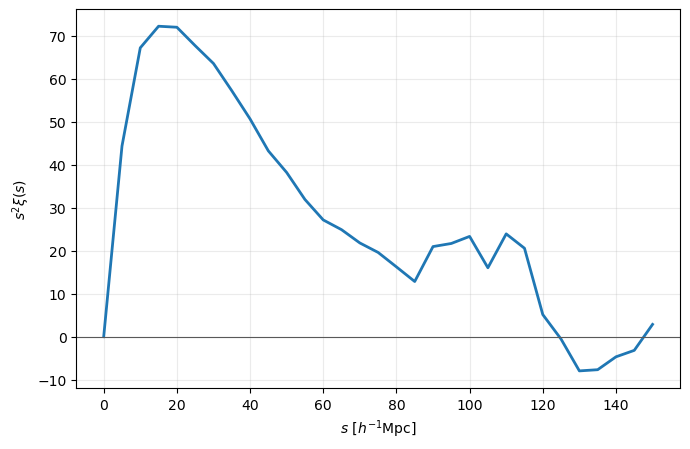

In [4]:
corr = Corr2PCFData(data_path="./output/quijote8000_snap004_2pcf.pkl")

fig, ax = plt.subplots(figsize=(7.0, 4.6))
ax.plot(corr.s, corr.s**2 * corr.xi, color="#1f77b4", lw=2.0)
ax.axhline(0.0, color="0.35", lw=0.8)
ax.set(xlabel=r"$s\ [h^{-1}\mathrm{Mpc}]$", ylabel=r"$s^2\xi(s)$")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig("./figs/quick_start_2pcf.png", dpi=180, bbox_inches="tight")
plt.show()
